In [1]:
from torchvision.transforms import transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from scipy import ndimage
from skimage.feature import hog
from scipy.signal import sepfir2d

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([transforms.Resize(128, 128), transforms.ToTensor(), transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

In [4]:
class EdgeDataset(Dataset):
    def __init__(self, train_dataset):
        self.dataset = train_dataset
        self.filter = np.array([[-0.1250, -0.2500, -0.1250], [0,0,0], [0.1250, 0.2500, 0.1250]])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        img_np = image.permute(1, 2, 0).numpy()
        img_gray = cv.cvtColor((img_np*255).astype(np.uint8), cv.COLOR_RGB2GRAY)
        new_img = cv.Canny(img_gray, 50, 150)
        new_img = new_img.astype("float32") / 255.0
        tensor = torch.tensor(new_img, dtype=torch.float32).unsqueeze(0)
        return tensor, label


In [5]:
train_data = datasets.ImageFolder(root='data/Train', transform=transform)
test_data  = datasets.ImageFolder(root='data/Test', transform=transform)

train_dataset, val_dataset = random_split(train_data, [12887, 3221])

batch_size = 32
train_dataset = EdgeDataset(train_dataset)
val_dataset = EdgeDataset(val_dataset)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

6
sad


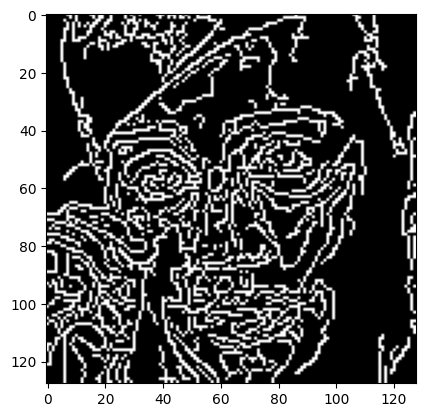

In [6]:
img, label = train_dataset[14]
img = img.squeeze(0)
plt.imshow(img, cmap='gray')
print(label)
print(train_data.classes[label])

In [7]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim = 1)
    return(torch.tensor(torch.sum(preds == labels).item()/ len(preds)))

In [8]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.conv3 = nn.Conv2d(64, 128, 3)
        self.conv4 = nn.Conv2d(128, 256, 3)
        self.batch_norm1 = nn.BatchNorm2d(32)
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.batch_norm3 = nn.BatchNorm2d(128)
        self.batch_norm4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout2d(p=0.3)
        self.fc1 = nn.Linear(256 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 8)

    def forward(self, xb):
        x = self.batch_norm1(self.conv1(xb))
        x = self.drop(self.pool(F.relu(x)))
        x = self.batch_norm2(self.conv2(x))
        x = self.drop(self.pool(F.relu(x)))
        x = self.batch_norm3(self.conv3(x))
        x = self.drop(self.pool(F.relu(x)))
        x = self.batch_norm4(self.conv4(x))
        x = self.drop(self.pool(F.relu(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def training_step(self, batch):
        images, labels = batch
        output = self(images)
        loss = F.cross_entropy(output, labels)
        acc = accuracy(output, labels)
        return loss, acc
    
    def validation_step(self, batch):
        images, labels = batch
        output = self(images)
        loss = F.cross_entropy(output, labels)
        acc = accuracy(output, labels)
        return({"val_loss": loss, "val_acc": acc})
    
    def validation_epoch_end(self, outputs): # computing the loss and acc after each batch
      batch_losses = [x['val_loss'] for x in outputs]
      epoch_loss = torch.stack(batch_losses).mean()
      batch_accs = [x['val_acc'] for x in outputs]
      epoch_acc = torch.stack(batch_accs).mean()
      return({'val_loss': epoch_loss.item(), 'val_acc' : epoch_acc.item()})
    
    def epoch_end(self, epoch, result): # final print statement at the end of each epoch
      print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))


model = Model().to(device)

In [ ]:
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return (model.validation_epoch_end(outputs))



def fit(epochs, lr, model, train_loader, val_loader, opt_function=torch.optim.SGD):
    history = []
    optimizer = opt_function(model.parameters(), lr=lr, momentum=0.9)

    for epoch in range(epochs):
        train_loss = 0
        train_acc = 0
        num_batches = 0

        for batch in train_loader:
            images, labels = batch
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss, acc = model.training_step((images, labels))
            loss.backward()

            train_loss += loss.item()
            train_acc += acc.item()
            num_batches += 1

            optimizer.step()

        epoch_loss = train_loss / num_batches
        epoch_acc = train_acc / num_batches
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
        print(f"train_loss: {epoch_loss:.4f}, train_acc: {epoch_acc:.4f}")

SyntaxError: invalid syntax (3123974993.py, line 29)

In [10]:
fit(10, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.8162, val_acc: 0.3044
train_loss: 1.9946, train_acc: 0.2238
Epoch [1], val_loss: 1.6014, val_acc: 0.3545
train_loss: 1.6948, train_acc: 0.3232
Epoch [2], val_loss: 1.5033, val_acc: 0.4037
train_loss: 1.5840, train_acc: 0.3733
Epoch [3], val_loss: 1.4366, val_acc: 0.4466
train_loss: 1.4988, train_acc: 0.4141
Epoch [4], val_loss: 1.3750, val_acc: 0.4733
train_loss: 1.4346, train_acc: 0.4380
Epoch [5], val_loss: 1.3654, val_acc: 0.4639
train_loss: 1.3860, train_acc: 0.4615
Epoch [6], val_loss: 1.3218, val_acc: 0.4855
train_loss: 1.3524, train_acc: 0.4743
Epoch [7], val_loss: 1.3158, val_acc: 0.4911
train_loss: 1.3251, train_acc: 0.4815
Epoch [8], val_loss: 1.3022, val_acc: 0.4892
train_loss: 1.2957, train_acc: 0.4925
Epoch [9], val_loss: 1.2746, val_acc: 0.5016
train_loss: 1.2694, train_acc: 0.5060


In [12]:
torch.save(model.state_dict(), "model_weights.pt")